# This notebook goes through a fundamental exploratory data analysis of the Kaggle Titanic dataset with Python.
Although this notebook works towards creating a Kaggle submission, it should not be taken as an exhaustive list of things to do with a dataset. It has been set up as an introduction to started with exploratory data analysis (EDA).

This is my first project on kaggle. I hope you guys like it.

Keep learning,

vikas singh

# What is EDA?
Exploratory Data Analysis refers to the critical process of performing initial investigations on data so as to discover patterns,to spot anomalies,to test hypothesis and to check assumptions with the help of summary statistics and graphical representations.

It is a good practice to understand the data first and try to gather as many insights from it. EDA is all about making sense of data in hand,before getting them dirty with it.

EDA explained using sample Data set:
To share my understanding of the concept and techniques I know,I’ll take an example of white variant of Wine Quality data set which is available on UCI Machine Learning Repository and try to catch hold of as many insights from the data set using EDA.

# Step 1: Download the data
You can download the data for this notebook here: https://www.kaggle.com/c/titanic/data


# Step 2: Work through the notebook
First we will import all the relevant dependencies we need.

If you don't have any of these, the notebook will throw an error. The error will likely tell you what you don't have. Then you'll have to install it.

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-whitegrid')

# Import Dependencies
%matplotlib inline

In [2]:
# Importing train data
train = pd.read_csv('../input/train.csv')

In [3]:
#let's check head of the dataset
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Data Insights

In [4]:
#Nuber of rows and columns
train.shape

(891, 12)

  * Data comprises 891 observation and 12 featurs
  * Out of that survival is depended variable and remaining 11 variable are the independent variables

In [5]:
#Name of the columns
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.6+ KB


   * Data has 2 float, 5 integer, and 5 object values
   * Age, Cabin, Embarked has null/missing values

# Summary Statistics

In [7]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


   * 38 percent passengers are survived out of 891.
   * average age of passengers onboard is 29.69.
   * average fare is around 32.20
   

# Data Visualization

### To check missing values

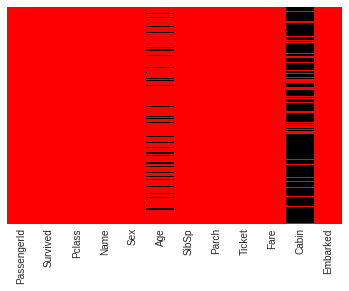

In [8]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap = 'flag')

   * In the heatmap, black lines are showing missing values in "Age",          "cabin", and "Embaeked".

### To check correlation

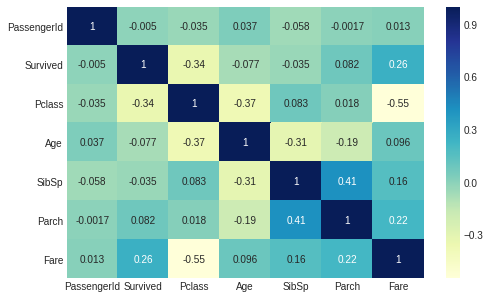

In [9]:
plt.figure(figsize=(8,5))
sns.heatmap(train.corr(), cmap='YlGnBu', annot=True)

   * Here we can deduce that weak correlation between the predictors            because corr value is less than +- 0.5.

### Target Feature: Survived
Description: Whether the passenger survived or not.

 Key: 0 = did not survive, 1 = survived

0    549
1    342
Name: Survived, dtype: int64


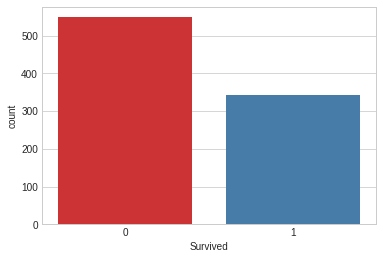

In [10]:
# how many passengers survied?
sns.countplot(data=train, x='Survived', palette='Set1')
print(train.Survived.value_counts())

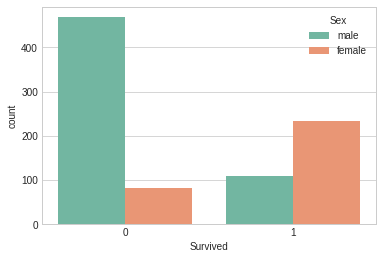

In [11]:
# how many male and female was survived?
sns.countplot(data=train, x='Survived', hue='Sex', palette='Set2')

   *  The survived passenger was not much. Mostly females was survived.

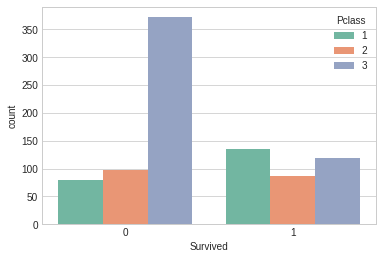

In [12]:
# Number of passengers was survived from the pclass 
sns.countplot(data=train, x='Survived', hue='Pclass', palette='Set2')

0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64


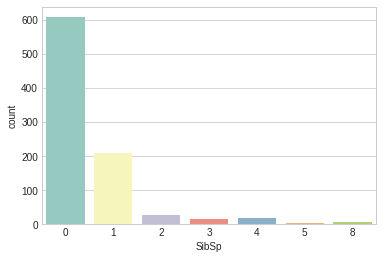

In [13]:
 # Number of siblings/spouses aboard the Titanic
sns.countplot(data=train, x='SibSp', palette='Set3')
print(train.SibSp.value_counts())

0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: Parch, dtype: int64


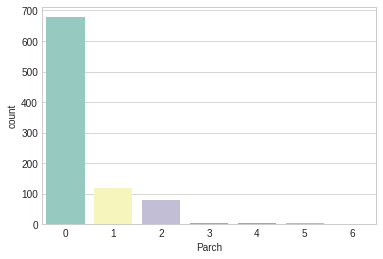

In [14]:
#  number of parents/children aboard the Titanic
sns.countplot(data=train, x='Parch', palette='Set3')
print(train.Parch.value_counts())

S    644
C    168
Q     77
Name: Embarked, dtype: int64


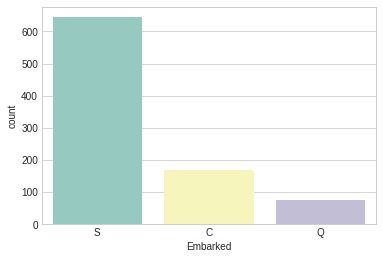

In [15]:
# Number of passengers abord from C = Cherbourg, Q = Queenstown, S = Southampton
sns.countplot(data=train, x='Embarked', palette='Set3')
print(train.Embarked.value_counts())

### Distribution
We will look at the distribution of each feature first if we can to understand what kind of spread there is across the dataset.

/opt/conda/lib/python3.6/site-packages/numpy/lib/histograms.py:829: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/opt/conda/lib/python3.6/site-packages/numpy/lib/histograms.py:830: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


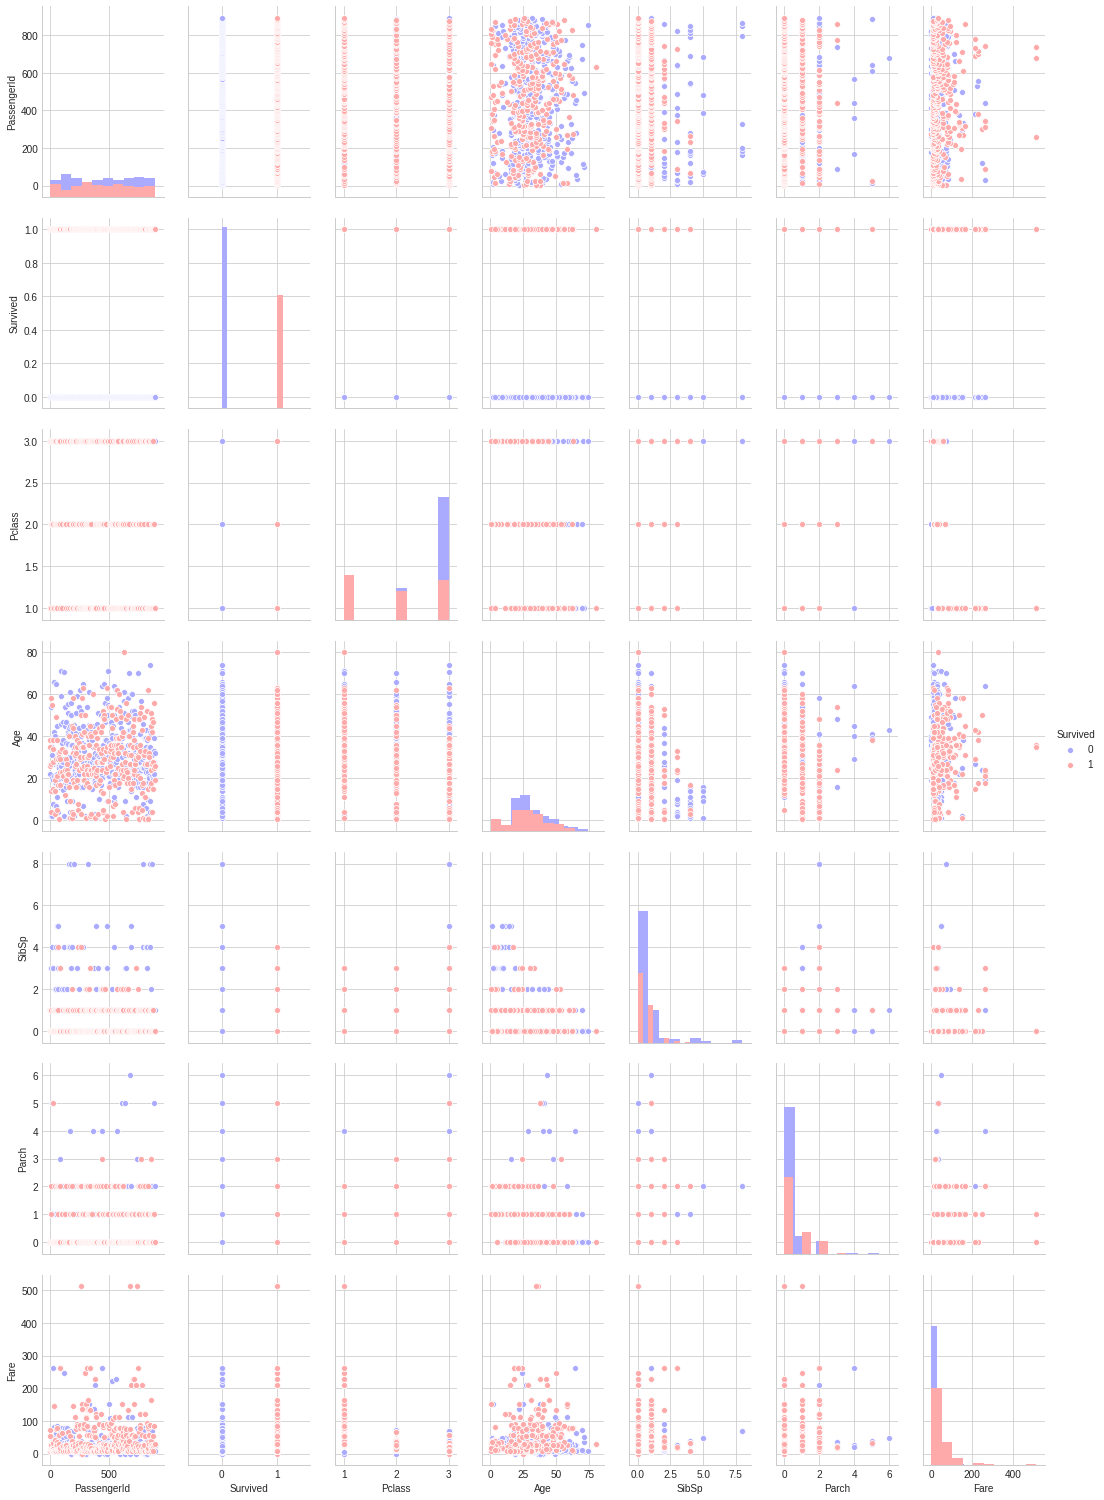

In [16]:
sns.pairplot(data=train, hue ='Survived', diag_kind='hist', height= 3, aspect=0.7,palette='bwr')

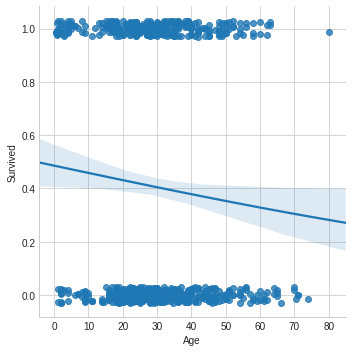

In [17]:
sns.lmplot(x='Age',y='Survived',data=train,logistic=True, y_jitter=.03, )

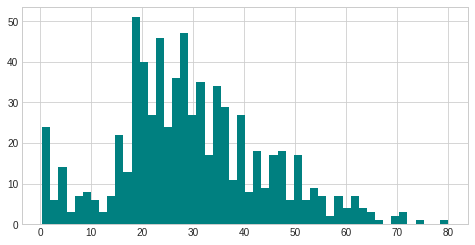

In [18]:
plt.figure(figsize=(8,4))
train['Age'].hist(bins=50, color='teal')

/opt/conda/lib/python3.6/site-packages/statsmodels/nonparametric/kde.py:447: RuntimeWarning: invalid value encountered in greater
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.
/opt/conda/lib/python3.6/site-packages/statsmodels/nonparametric/kde.py:447: RuntimeWarning: invalid value encountered in less
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.


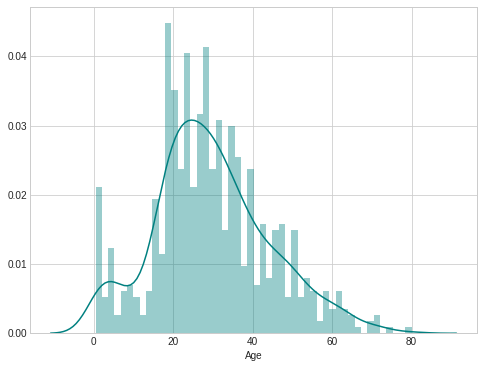

In [19]:
plt.figure(figsize=(8,6))
sns.distplot(train['Age'], bins=50, color='teal')

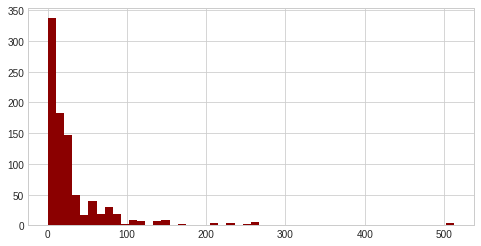

In [20]:
plt.figure(figsize=(8,4))
train['Fare'].hist(bins=50, color='darkred')

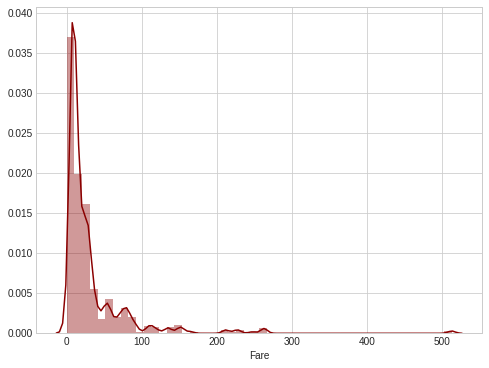

In [21]:
plt.figure(figsize=(8,6))
sns.distplot(train['Fare'].dropna(), bins=50, color='darkred')

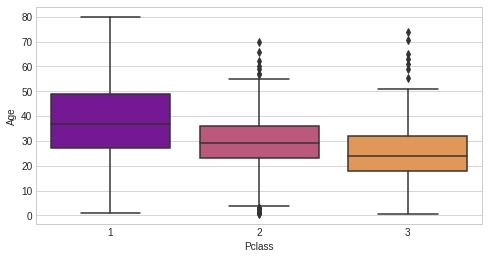

In [22]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="Pclass", y="Age", data=train,palette='plasma')

  * In class_1, average age of the passengers is 37.
  * In class_2, average age of the passengers is 29.
  * In class_3, average age of the passengers is 24.

### Outliers Detection 

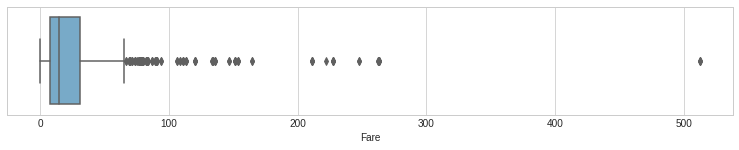

In [23]:
plt.figure(figsize=(13, 2))
sns.boxplot(x=train["Fare"],palette='Blues')

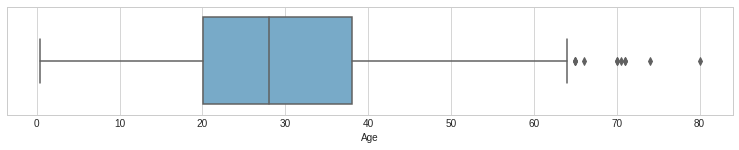

In [24]:
plt.figure(figsize=(13, 2))
sns.boxplot(x=train["Age"],palette='Blues')